In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported!")

All libraries imported!


In [42]:
hotels_df = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/hotels.csv')
users_df = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/users.csv')
reviews_df = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/reviews.csv')

print("Data loaded successfully!")
print(f" Hotels: {len(hotels_df)} records")
print(f" Users: {len(users_df)} records") 
print(f" Reviews: {len(reviews_df)} records")
print(f" Date range: {reviews_df['review_date'].min()} to {reviews_df['review_date'].max()}")

Data loaded successfully!
 Hotels: 25 records
 Users: 2000 records
 Reviews: 50000 records
 Date range: 2020-01-01 to 2025-12-31


In [43]:
import os
for root,dirs,files in os.walk("/kaggle/input"):
    print(root,files)

/kaggle/input []
/kaggle/input/international-hotel-booking-analytics ['users.csv', 'booking_db.sqlite', 'reviews.csv', 'hotels.csv']


In [44]:

# Basic Dimensions and Columns
print("Dataset Dimensions and Features")
print("-" * 60)
rows, columns = hotels_df.shape
print(f"Total Records: {rows}")
print(f"Total Fields: {columns}")
print(f"Feature Names: {hotels_df.columns.tolist()}")

# Previewing Data
print("\n Preview of Dataset Entries")
print("-" * 60)
display(hotels_df.head())

# Structural Summary
print("\n Dataset Information")
print("-" * 60)
hotels_df.info()

# Country-wise Distribution
print("\n Distribution by Country")
print("-" * 60)
country_counts = hotels_df['country'].value_counts()
print(country_counts)

# Descriptive Statistics for Rating Metrics
print("\n Summary of Initial Ratings")
print("-" * 60)
initial_rating_fields = [
    'cleanliness_base',
    'comfort_base',
    'facilities_base',
    'location_base',
    'staff_base',
    'value_for_money_base'
]
rating_summary = hotels_df[initial_rating_fields].describe()
print(rating_summary)


Dataset Dimensions and Features
------------------------------------------------------------
Total Records: 25
Total Fields: 13
Feature Names: ['hotel_id', 'hotel_name', 'city', 'country', 'star_rating', 'lat', 'lon', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base']

 Preview of Dataset Entries
------------------------------------------------------------


,hotel_id,hotel_name,city,country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0
1,2,The Royal Compass,London,United Kingdom,5,51.5072,-0.1276,9.0,9.2,8.8,9.4,9.0,7.9
2,3,L'Étoile Palace,Paris,France,5,48.8566,2.3522,8.8,9.4,8.7,9.6,9.3,8.1
3,4,Kyo-to Grand,Tokyo,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2
4,5,The Golden Oasis,Dubai,United Arab Emirates,5,25.2769,55.2962,9.3,9.5,9.6,8.9,9.4,8.5



 Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hotel_id              25 non-null     int64  
 1   hotel_name            25 non-null     object 
 2   city                  25 non-null     object 
 3   country               25 non-null     object 
 4   star_rating           25 non-null     int64  
 5   lat                   25 non-null     float64
 6   lon                   25 non-null     float64
 7   cleanliness_base      25 non-null     float64
 8   comfort_base          25 non-null     float64
 9   facilities_base       25 non-null     float64
 10  location_base         25 non-null     float64
 11  staff_base            25 non-null     float64
 12  value_for_money_base  25 non-null     float64
dtypes: float64(8), int64(2), object(3)
memory us

In [45]:
#users table


print("=" * 50)
print(f"Shape: {users_df.shape}")
print(f"Columns: {list(users_df.columns)}")
print("\nFirst 5 users:")
display(users_df.head())

print("\n📊 USERS DATASET SUMMARY")
print("=" * 50)
print(users_df.info())

print("\n👤 DEMOGRAPHIC BREAKDOWN")
print("=" * 50)
print("Gender Distribution:")
print(users_df['user_gender'].value_counts())
print(f"Percentage: {users_df['user_gender'].value_counts(normalize=True)*100}")

print("\n🎂 Age Group Distribution:")
print(users_df['age_group'].value_counts())

print("\n🧳 Traveller Type Distribution:")
print(users_df['traveller_type'].value_counts())

print("\n🌍 Top 10 Countries by Users:")
print(users_df['country'].value_counts().head(10))

# Convert join_date to datetime for analysis
users_df['join_date'] = pd.to_datetime(users_df['join_date'])
print(f"\n📅 User Registration Period: {users_df['join_date'].min().date()} to {users_df['join_date'].max().date()}")

Shape: (2000, 6)
Columns: ['user_id', 'user_gender', 'country', 'age_group', 'traveller_type', 'join_date']

First 5 users:


,user_id,user_gender,country,age_group,traveller_type,join_date
0,1,Female,United Kingdom,35-44,Solo,2024-09-29
1,2,Male,United Kingdom,25-34,Solo,2023-11-29
2,3,Female,Mexico,25-34,Family,2022-04-03
3,4,Male,India,35-44,Family,2023-12-02
4,5,Other,Japan,25-34,Solo,2021-12-18



📊 USERS DATASET SUMMARY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         2000 non-null   int64 
 1   user_gender     2000 non-null   object
 2   country         2000 non-null   object
 3   age_group       2000 non-null   object
 4   traveller_type  2000 non-null   object
 5   join_date       2000 non-null   object
dtypes: int64(1), object(5)
memory usage: 93.9+ KB
None

👤 DEMOGRAPHIC BREAKDOWN
Gender Distribution:
user_gender
Male      942
Female    864
Other     194
Name: count, dtype: int64
Percentage: user_gender
Male      47.1
Female    43.2
Other      9.7
Name: proportion, dtype: float64

🎂 Age Group Distribution:
age_group
25-34    653
35-44    611
45-54    317
18-24    218
55+      201
Name: count, dtype: int64

🧳 Traveller Type Distribution:
traveller_type
Couple      694
Family      478
Solo        420
Business  

In [46]:

# Reviews Dataset

# Basic Structure
print("📝 Reviews Dataset Overview")
print("-" * 60)
print(f"Entries: {reviews_df.shape[0]}")
print(f"Attributes: {reviews_df.shape[1]}")
print(f"Available Columns: {reviews_df.columns.tolist()}")

# Preview Sample Records
print("\n🔍 Sample Review Entries")
print("-" * 60)
display(reviews_df.head(5))

# Dataset Summary
print("\n📋 Dataset Info")
print("-" * 60)
reviews_df.info()

# Ensure review_date is in datetime format
reviews_df['review_date'] = pd.to_datetime(reviews_df['review_date'])

# Temporal Trends
print("\n📅 Review Timeline")
print("-" * 60)
start_date = reviews_df['review_date'].min().date()
end_date = reviews_df['review_date'].max().date()
print(f"Date Range: {start_date} to {end_date}")

# Reviews by Year
reviews_df['year'] = reviews_df['review_date'].dt.year
print("\nReviews per Year:")
print(reviews_df['year'].value_counts().sort_index())

# Rating Columns Summary
print("\n⭐ Rating Breakdown")
print("-" * 60)
rating_fields = [
    'score_overall', 'score_cleanliness', 'score_comfort',
    'score_facilities', 'score_location', 'score_staff', 'score_value_for_money'
]
print("Summary Statistics for Rating Fields:")
display(reviews_df[rating_fields].describe())

# Reviews per Hotel
print("\n🏨 Distribution: Reviews per Hotel")
print("-" * 60)
hotel_review_counts = reviews_df['hotel_id'].value_counts().sort_index()
print(f"Average Reviews per Hotel: {hotel_review_counts.mean():.1f}")
print(f"Minimum Reviews: {hotel_review_counts.min()}")
print(f"Maximum Reviews: {hotel_review_counts.max()}")

# Reviews per User
print("\n👤 User Activity Overview")
print("-" * 60)
user_review_counts = reviews_df['user_id'].value_counts()
print(f"Average Reviews per User: {user_review_counts.mean():.1f}")
print(f"Users with >1 Review: {(user_review_counts > 1).sum()}")
print(f"Top Reviewer: {user_review_counts.max()} reviews")





📝 Reviews Dataset Overview
------------------------------------------------------------
Entries: 50000
Attributes: 12
Available Columns: ['review_id', 'user_id', 'hotel_id', 'review_date', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'score_staff', 'score_value_for_money', 'review_text']

🔍 Sample Review Entries
------------------------------------------------------------


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money,review_text
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7,Practice reduce young our because machine. Rec...
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6,Test cover traditional black. Process tell Mr ...
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6,Friend million student social study yeah. Grow...
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,8.3,Huge girl already remain truth behind card. Ap...
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,8.9,Cover feeling call community serve television ...



📋 Dataset Info
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   review_id              50000 non-null  int64  
 1   user_id                50000 non-null  int64  
 2   hotel_id               50000 non-null  int64  
 3   review_date            50000 non-null  object 
 4   score_overall          50000 non-null  float64
 5   score_cleanliness      50000 non-null  float64
 6   score_comfort          50000 non-null  float64
 7   score_facilities       50000 non-null  float64
 8   score_location         50000 non-null  float64
 9   score_staff            50000 non-null  float64
 10  score_value_for_money  50000 non-null  float64
 11  review_text            50000 non-null  object 
dtypes: float64(7), int64(3), object(2)
memory usage: 4.6+ MB

📅 Review Timeline
-----

,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,8.943460,9.052558,9.024404,8.743062,9.176410,8.972076,8.434540
std,0.180878,0.504296,0.423927,0.498320,0.421086,0.397775,0.529321
min,8.200000,7.700000,7.900000,7.600000,7.900000,7.900000,6.800000
25%,8.800000,8.700000,8.700000,8.400000,8.900000,8.700000,8.100000
50%,8.900000,9.100000,9.000000,8.700000,9.200000,9.000000,8.500000
75%,9.100000,9.400000,9.300000,9.100000,9.500000,9.200000,8.800000
max,9.600000,10.000000,10.000000,10.000000,10.000000,10.000000,9.700000



🏨 Distribution: Reviews per Hotel
------------------------------------------------------------
Average Reviews per Hotel: 2000.0
Minimum Reviews: 1902
Maximum Reviews: 2104

👤 User Activity Overview
------------------------------------------------------------
Average Reviews per User: 25.0
Users with >1 Review: 2000
Top Reviewer: 44 reviews


📉 Visualizing Missing Data


<Figure size 1000x500 with 0 Axes>

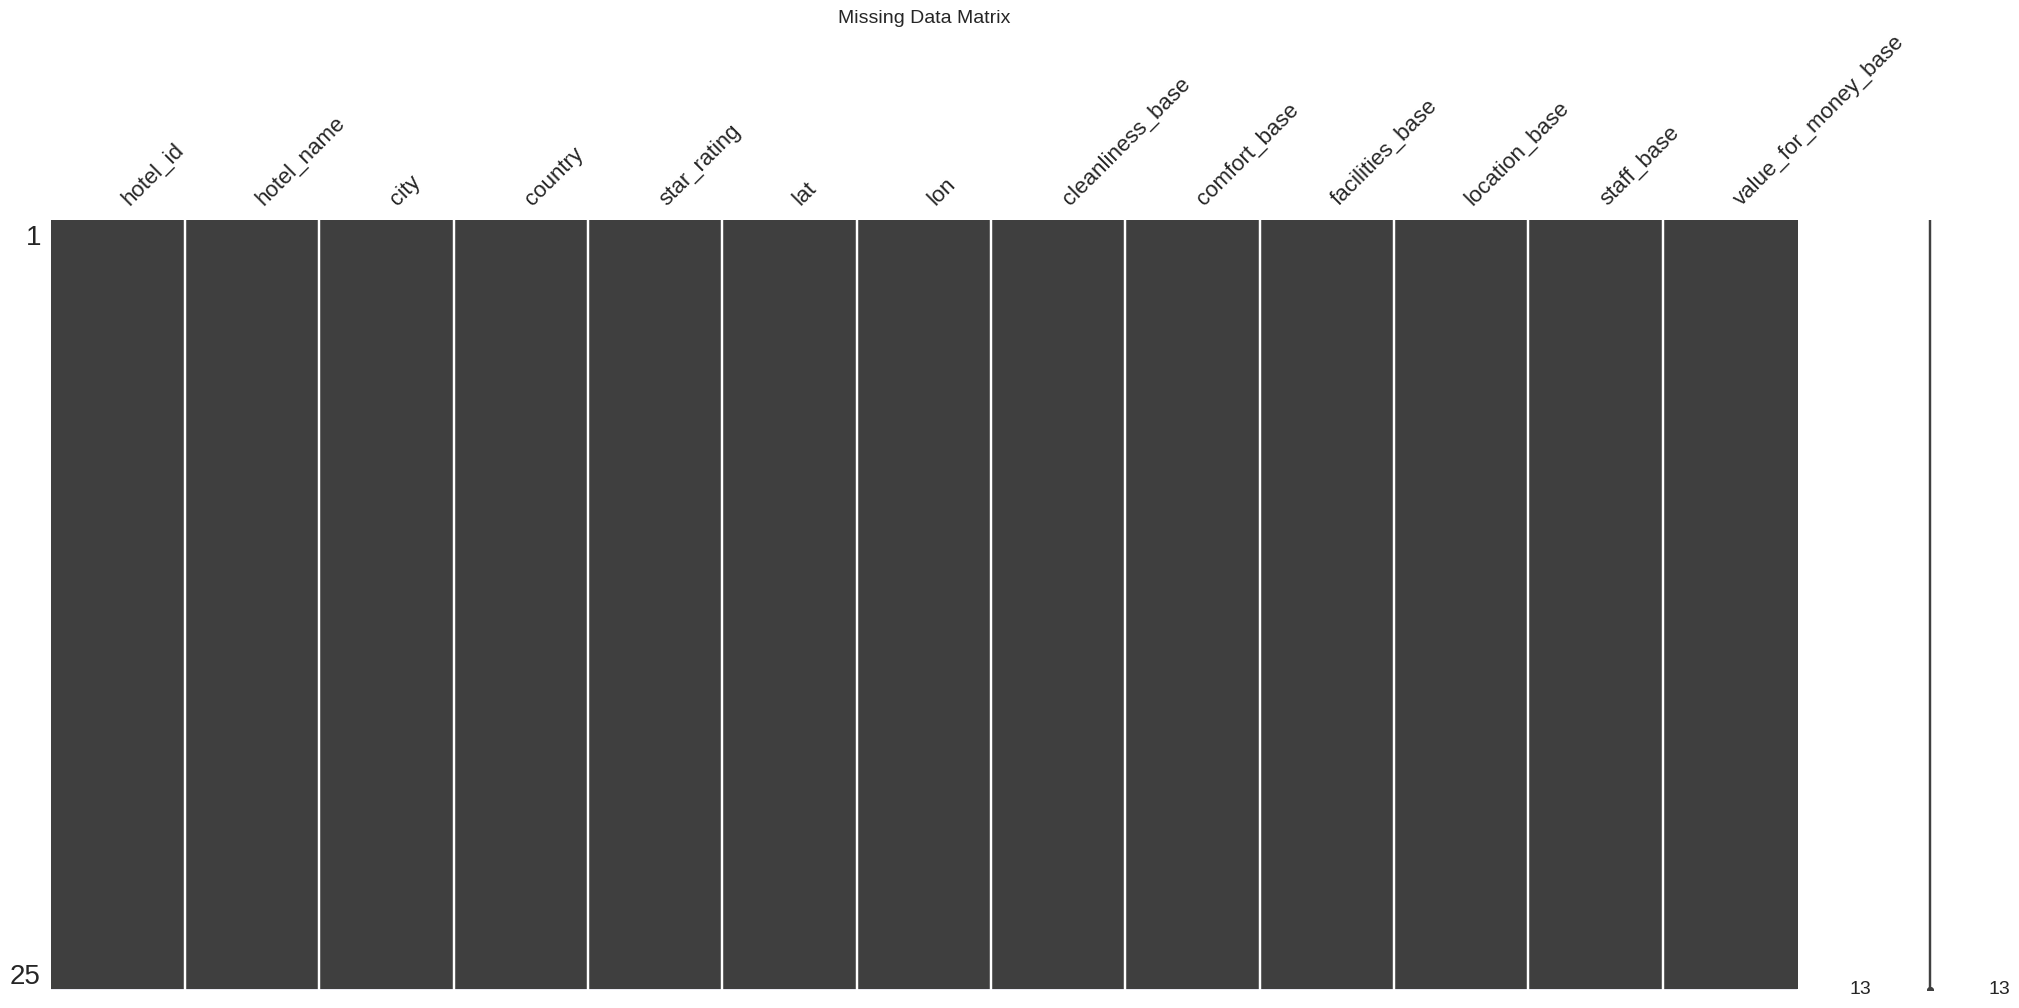


🧮 Missing Values Count
hotel_id                0
hotel_name              0
city                    0
country                 0
star_rating             0
lat                     0
lon                     0
cleanliness_base        0
comfort_base            0
facilities_base         0
location_base           0
staff_base              0
value_for_money_base    0
dtype: int64
📉 Visualizing Missing Data


<Figure size 1000x500 with 0 Axes>

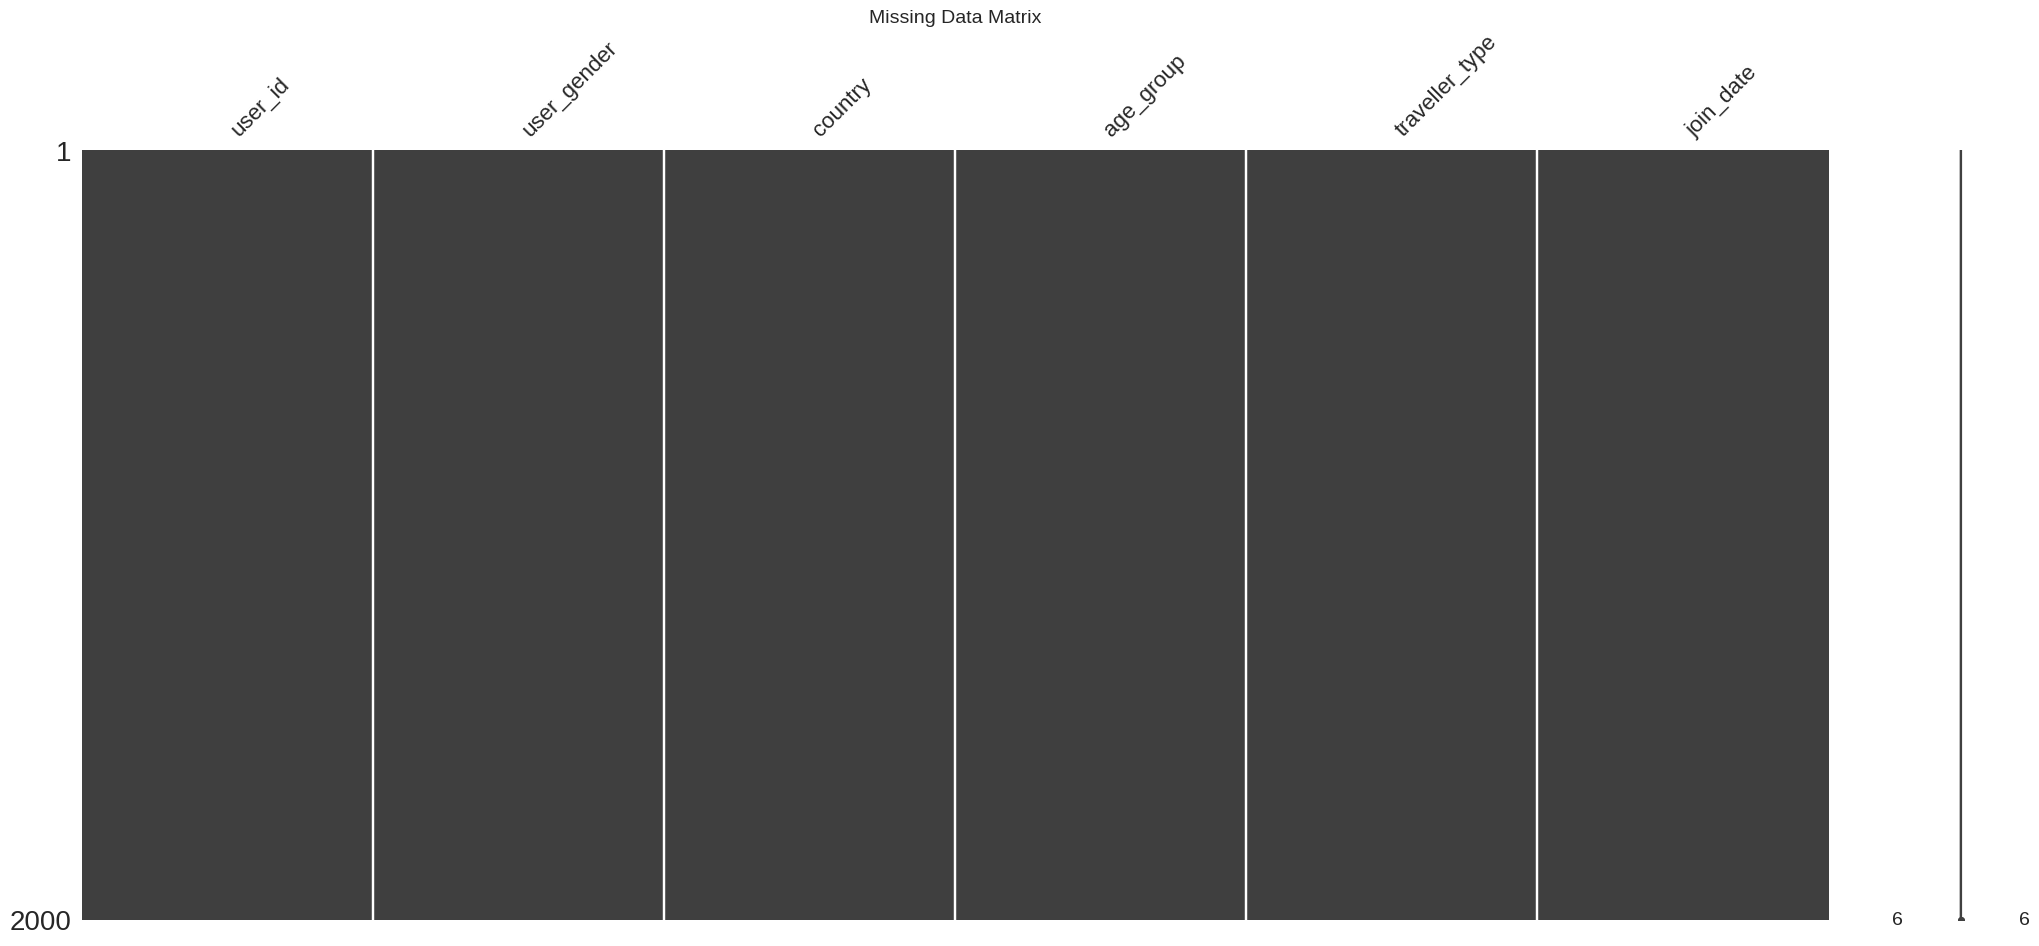


🧮 Missing Values Count
user_id           0
user_gender       0
country           0
age_group         0
traveller_type    0
join_date         0
dtype: int64
📉 Visualizing Missing Data


<Figure size 1000x500 with 0 Axes>

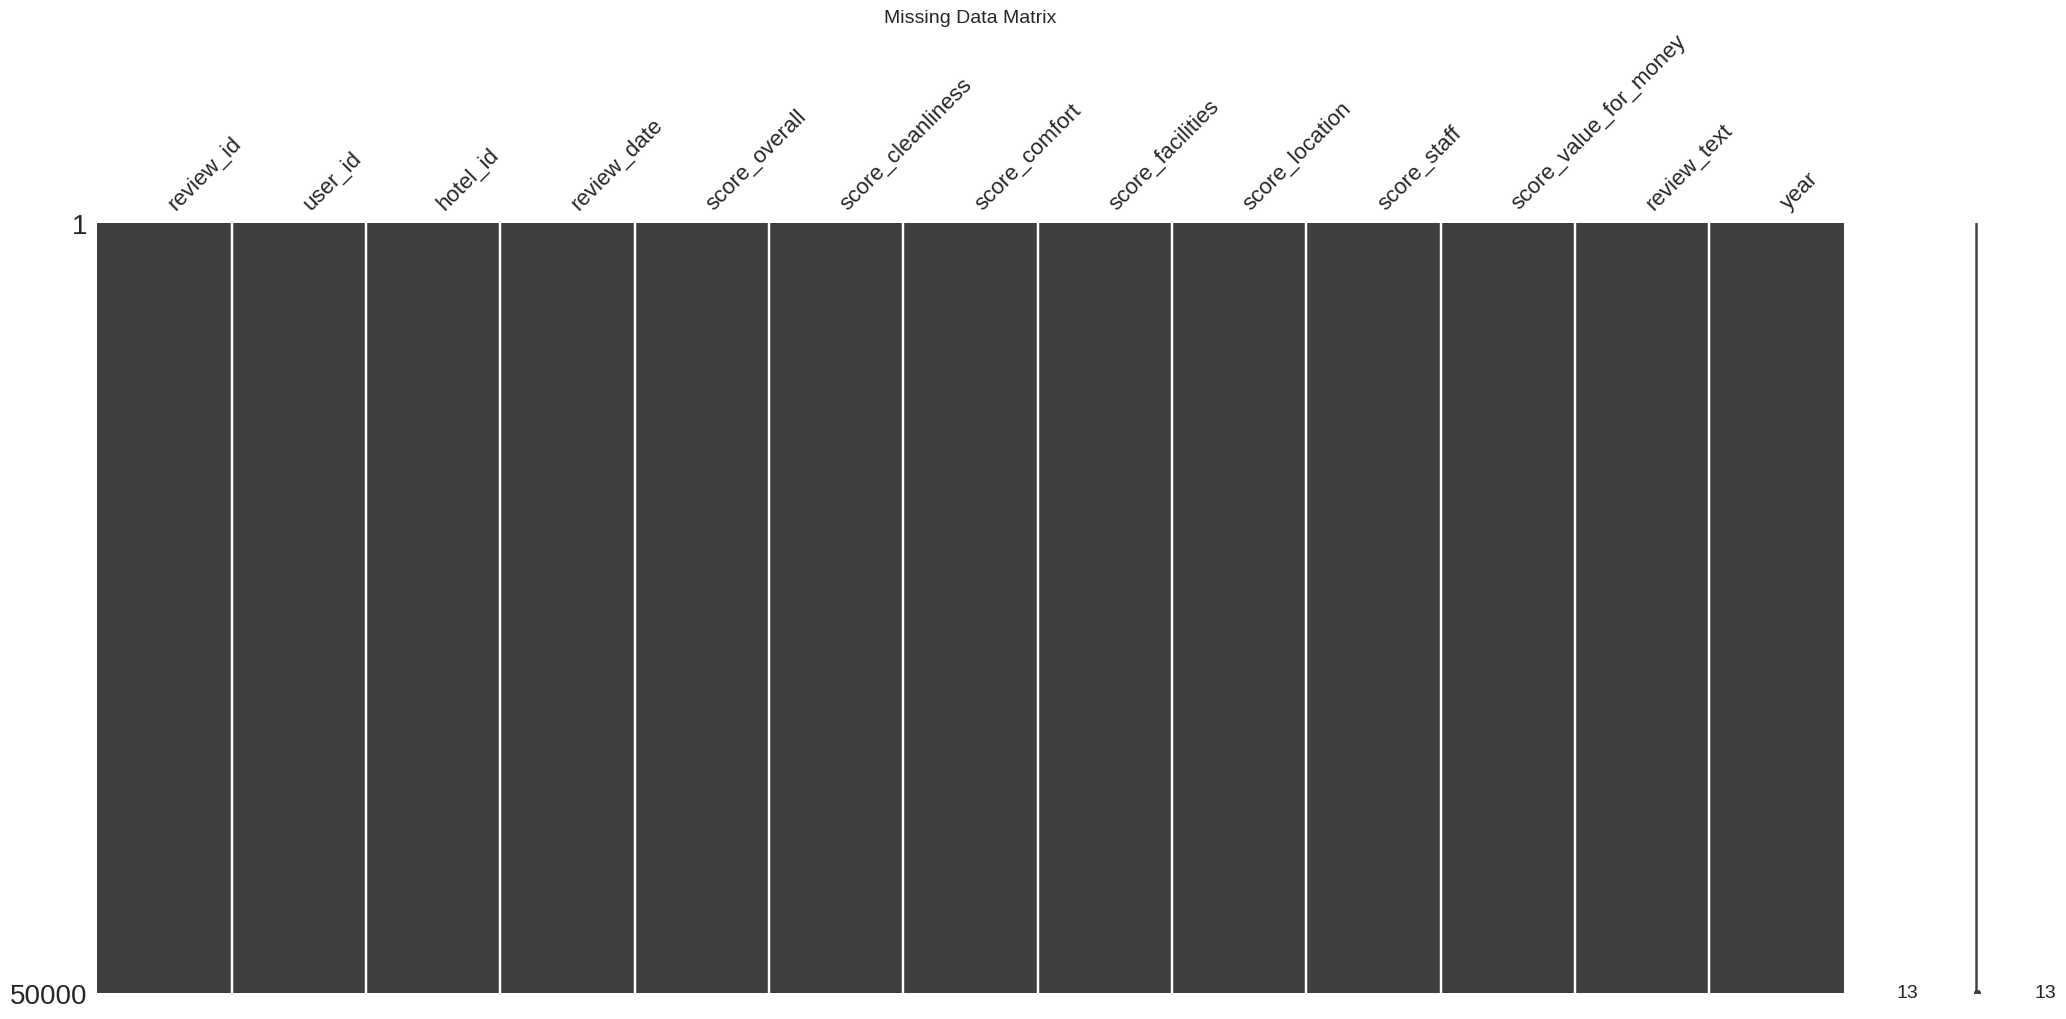


🧮 Missing Values Count
review_id                0
user_id                  0
hotel_id                 0
review_date              0
score_overall            0
score_cleanliness        0
score_comfort            0
score_facilities         0
score_location           0
score_staff              0
score_value_for_money    0
review_text              0
year                     0
dtype: int64


In [47]:
import missingno as msno
import matplotlib.pyplot as plt

# 1. Draw missing data matrix
print("📉 Visualizing Missing Data")
plt.figure(figsize=(10, 5))  # Optional: adjust size
msno.matrix(hotels_df)
plt.title("Missing Data Matrix", fontsize=14)
plt.show()

# 2. Print missing value counts
print("\n🧮 Missing Values Count")
print(hotels_df.isnull().sum())


# 1. Draw missing data matrix
print("📉 Visualizing Missing Data")
plt.figure(figsize=(10, 5))  # Optional: adjust size
msno.matrix(users_df)
plt.title("Missing Data Matrix", fontsize=14)
plt.show()

# 2. Print missing value counts
print("\n🧮 Missing Values Count")
print(users_df.isnull().sum())

# 1. Draw missing data matrix
print("📉 Visualizing Missing Data")
plt.figure(figsize=(10, 5))  # Optional: adjust size
msno.matrix(reviews_df)
plt.title("Missing Data Matrix", fontsize=14)
plt.show()

# 2. Print missing value counts
print("\n🧮 Missing Values Count")
print(reviews_df.isnull().sum())

In [48]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Prepare data
country_counts = hotels_df['country'].value_counts()
user_countries = users_df['country'].value_counts().head(15)

# Create subplot grid (1 row reserved for map or projection, if needed later)
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "geo", "colspan": 2}, None],  # Optional: map (row 1)
           [{"type": "xy"}, {"type": "xy"}]],       # Row 2: bar charts
    subplot_titles=("Hotels by Country", "Users by Country")
)

# Optional: World map (can be replaced or removed if not needed)
fig.add_trace(
    go.Scattergeo(
        locations=country_counts.index,
        locationmode='country names',
        marker=dict(size=10, color='blue'),
        name="Hotel Locations"
    ),
    row=1, col=1
)

# Hotels by country (horizontal bar chart)
fig.add_trace(
    go.Bar(
        x=country_counts.values,
        y=country_counts.index,
        orientation='h',
        marker_color='lightblue',
        name='Hotels by Country'
    ),
    row=2, col=1
)

# Users by country (vertical bar chart)
fig.add_trace(
    go.Bar(
        x=user_countries.index,
        y=user_countries.values,
        marker_color='lightcoral',
        name='Users by Country'
    ),
    row=2, col=2
)

# Layout updates
fig.update_layout(
    title_text="🏨 Hotel Booking Analytics: Geographic Distribution",
    height=800,
    showlegend=False,
    geo=dict(projection_type="equirectangular")
)

# Axis titles and ticks
fig.update_xaxes(title_text="Number of Hotels", row=2, col=1)
fig.update_yaxes(title_text="Country", row=2, col=1)
fig.update_xaxes(title_text="Country", row=2, col=2, tickangle=45)
fig.update_yaxes(title_text="Number of Users", row=2, col=2)

# Show the interactive plot
fig.show()

# Insights summary
print("📊 Key Geographic Insights:")
print(f"• Hotels span {hotels_df['country'].nunique()} countries.")
print(f"• Users represent {users_df['country'].nunique()} countries.")
print(f"• Top user countries: {', '.join(user_countries.head(5).index.tolist())}")
print(f"• Wide international hotel coverage, including major global cities.")


📊 Key Geographic Insights:
• Hotels span 25 countries.
• Users represent 25 countries.
• Top user countries: United States, United Kingdom, Germany, China, France
• Wide international hotel coverage, including major global cities.


In [49]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

print("📅 TEMPORAL ANALYSIS")
print("=" * 60)

# Step 1: Prepare time-based columns
reviews_df['year_month'] = reviews_df['review_date'].dt.to_period('M')
reviews_df['month'] = reviews_df['review_date'].dt.month
reviews_df['day_of_week'] = reviews_df['review_date'].dt.day_name()
users_df['reg_year_month'] = users_df['join_date'].dt.to_period('M')

# Step 2: Create subplot structure
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Reviews Over Time (Monthly)', 
        'Seasonal Patterns', 
        'Day of Week Patterns', 
        'User Registration Trends'
    ],
    specs=[
        [{"secondary_y": True}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}]
    ]
)

# Step 3: Monthly review trends
monthly_data = reviews_df.groupby('year_month').agg({
    'review_id': 'count',
    'score_overall': 'mean'
}).reset_index()
monthly_data['year_month_str'] = monthly_data['year_month'].astype(str)

# Review count
fig.add_trace(
    go.Scatter(
        x=monthly_data['year_month_str'],
        y=monthly_data['review_id'],
        mode='lines+markers',
        name='Review Count',
        line=dict(color='blue')
    ),
    row=1, col=1, secondary_y=False
)

# Average rating
fig.add_trace(
    go.Scatter(
        x=monthly_data['year_month_str'],
        y=monthly_data['score_overall'],
        mode='lines+markers',
        name='Average Rating',
        line=dict(color='red')
    ),
    row=1, col=1, secondary_y=True
)

# Step 4: Seasonal review counts by month
seasonal_data = reviews_df.groupby('month').agg({
    'review_id': 'count',
    'score_overall': 'mean'
}).reset_index()

fig.add_trace(
    go.Bar(
        x=seasonal_data['month'],
        y=seasonal_data['review_id'],
        name='Reviews by Month',
        marker_color='lightgreen'
    ),
    row=1, col=2
)

# Step 5: Day of the week patterns
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data = reviews_df.groupby('day_of_week')['review_id'].count().reindex(dow_order)

fig.add_trace(
    go.Bar(
        x=dow_data.index,
        y=dow_data.values,
        name='Reviews by Day',
        marker_color='orange'
    ),
    row=2, col=1
)

# Step 6: User registration trends
reg_data = users_df.groupby('reg_year_month').size().reset_index(name='user_count')
reg_data['reg_year_month_str'] = reg_data['reg_year_month'].astype(str)

fig.add_trace(
    go.Scatter(
        x=reg_data['reg_year_month_str'],
        y=reg_data['user_count'],
        mode='lines+markers',
        name='User Registrations',
        line=dict(color='purple')
    ),
    row=2, col=2
)

# Step 7: Update layout and axes
fig.update_layout(
    title_text="📈 Hotel Booking Analytics: Temporal Patterns",
    height=800,
    showlegend=True
)

# Axes updates
fig.update_xaxes(title_text="Month-Year", tickangle=45, row=1, col=1)
fig.update_yaxes(title_text="Review Count", row=1, col=1)
fig.update_yaxes(title_text="Avg Rating", row=1, col=1, secondary_y=True)

fig.update_xaxes(title_text="Month", row=1, col=2)
fig.update_yaxes(title_text="Review Count", row=1, col=2)

fig.update_xaxes(title_text="Day of Week", tickangle=45, row=2, col=1)
fig.update_yaxes(title_text="Review Count", row=2, col=1)

fig.update_xaxes(title_text="Month-Year", tickangle=45, row=2, col=2)
fig.update_yaxes(title_text="New Users", row=2, col=2)

# Step 8: Show the figure
fig.show()

# Step 9: Key insights
print("📊 Key Temporal Insights:")
print(f"• Review volume is consistent: {reviews_df.groupby('year')['review_id'].count().std():.0f} std deviation across years")
print(f"• Peak review months: {seasonal_data.nlargest(3, 'review_id')['month'].values}")
print(f"• Most active review day: {dow_data.idxmax()}")
print(f"• Average monthly reviews: {monthly_data['review_id'].mean():.0f}")
print(f"• Rating stability over time: {monthly_data['score_overall'].std():.3f} std deviation")


📅 TEMPORAL ANALYSIS


📊 Key Temporal Insights:
• Review volume is consistent: 52 std deviation across years
• Peak review months: [7 6 5]
• Most active review day: Wednesday
• Average monthly reviews: 694
• Rating stability over time: 0.007 std deviation


In [50]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Merge users and reviews to get country info per review
merged_df = reviews_df.merge(users_df[['user_id', 'country']], on='user_id', how='left')

# Compute average "value for money" score per country
country_value = (
    merged_df.groupby('country')['score_value_for_money']
    .mean()
    .sort_values(ascending=False)
)

# Select top 3 countries
top_countries = country_value.head(3)

# Print the information
print("🏆 Top 3 Countries by Average Value for Money Score")
print(top_countries.reset_index().rename(columns={
    'country': 'Country',
    'score_value_for_money': 'Avg Value for Money'
}))
print("\n------------------------------------------------------------\n")

# Create a new figure (avoids overlap)
fig = make_subplots(rows=1, cols=1, subplot_titles=["Top 3 Countries by Value for Money"])

# Add bar chart
fig.add_trace(
    go.Bar(
        x=top_countries.index,
        y=top_countries.values,
        marker_color='lightcoral',
        name='Avg Value for Money'
    ),
    row=1, col=1
)

# Customize layout
fig.update_layout(
    height=400,
    width=700,
    title_text="Top 3 User Countries Based on Value for Money",
    showlegend=False,
    bargap=0.4
)
fig.update_xaxes(title_text="Country")
fig.update_yaxes(title_text="Average Value for Money Score", range=[0, top_countries.max() + 0.5])

# Display the figure
fig.show()


🏆 Top 3 Countries by Average Value for Money Score
     Country  Avg Value for Money
0  Singapore             8.597297
1  Argentina             8.553804
2      Egypt             8.540341

------------------------------------------------------------



🏙 Best City per Traveler Type:

        city traveller_type  score_overall
0      Dubai         Family       9.214381
1  Amsterdam           Solo       9.108454
2  Amsterdam         Couple       9.096989
3      Dubai       Business       8.965668


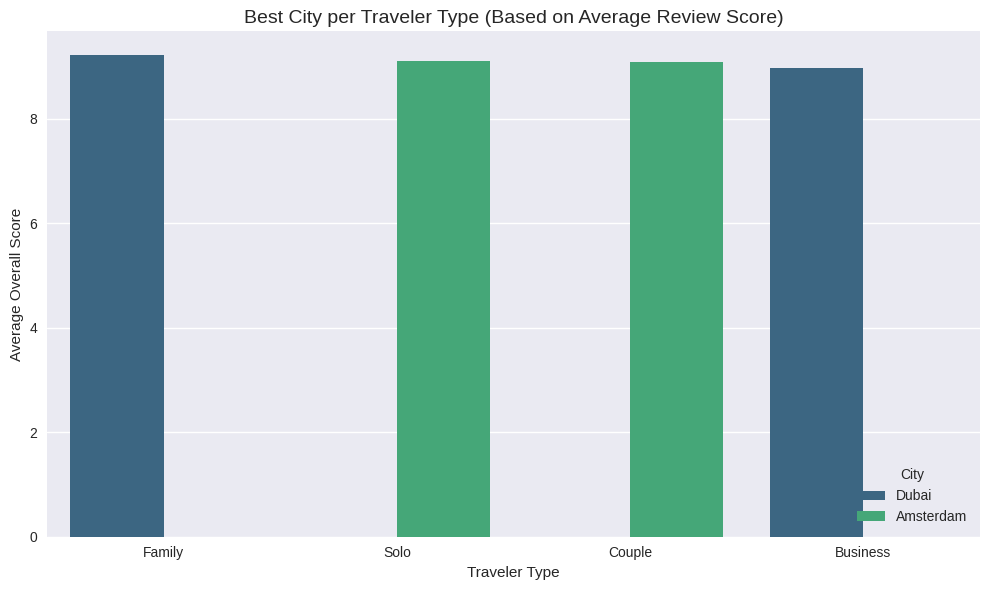

In [51]:
merged_df = (
    reviews_df
    .merge(users_df, on="user_id", how="left")
    .merge(hotels_df, on="hotel_id", how="left")
)

# ------------------------------------------------------------
# ⿤ Compute average review score per (city, traveler_type)
# ------------------------------------------------------------
city_traveler_avg = (
    merged_df.groupby(["city", "traveller_type"])["score_overall"]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# ⿥ Find the best city for each traveler type
# ------------------------------------------------------------
best_city_per_type = (
    city_traveler_avg.loc[
        city_traveler_avg.groupby("traveller_type")["score_overall"].idxmax()
    ]
    .sort_values("score_overall", ascending=False)
    .reset_index(drop=True)
)
print("🏙 Best City per Traveler Type:\n")
print(best_city_per_type)

# ------------------------------------------------------------
# ⿦ Visualization - Which city performs best for each traveler type?
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(
    data=best_city_per_type,
    x="traveller_type",
    y="score_overall",
    hue="city",
    palette="viridis"
)

plt.title("Best City per Traveler Type (Based on Average Review Score)", fontsize=14)
plt.xlabel("Traveler Type")
plt.ylabel("Average Overall Score")
plt.legend(title="City", loc="lower right")
plt.tight_layout()
plt.show()

In [52]:
import plotly.graph_objects as go

# ------------------------------------------------------------
# ✅ Data Prep (same as your version)
# ------------------------------------------------------------
merged_df = (
    reviews_df
    .merge(users_df, on="user_id", how="left")
    .merge(hotels_df, on="hotel_id", how="left")
)

# Compute average overall score per (city, traveler_type)
city_traveler_avg = (
    merged_df.groupby(["city", "traveller_type"])["score_overall"]
    .mean()
    .reset_index()
)

# Find the best city for each traveler type
best_city_per_type = (
    city_traveler_avg.loc[
        city_traveler_avg.groupby("traveller_type")["score_overall"].idxmax()
    ]
    .sort_values("score_overall", ascending=False)
    .reset_index(drop=True)
)

# Display table
print("🏙 Best City per Traveler Type:\n")
print(best_city_per_type.rename(columns={
    "traveller_type": "Traveler Type",
    "city": "Best City",
    "score_overall": "Avg Overall Score"
}).to_string(index=False))
print("\n------------------------------------------------------------\n")

# ------------------------------------------------------------
# 📈 Visualization - Plotly style (same look as previous graphs)
# ------------------------------------------------------------
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=best_city_per_type["traveller_type"],
        y=best_city_per_type["score_overall"],
        text=best_city_per_type["city"],
        textposition="auto",
        marker_color="lightcoral",
        name="Best City"
    )
)

# Layout settings for consistency
fig.update_layout(
    title="Best City per Traveler Type (Based on Average Review Score)",
    xaxis_title="Traveler Type",
    yaxis_title="Average Overall Score",
    height=500,
    width=800,
    bargap=0.4,
    showlegend=False,
    title_x=0.5
)

fig.show()


🏙 Best City per Traveler Type:

Best City Traveler Type  Avg Overall Score
    Dubai        Family           9.214381
Amsterdam          Solo           9.108454
Amsterdam        Couple           9.096989
    Dubai      Business           8.965668

------------------------------------------------------------



In [53]:
hotels_df['country_group'] = None
hotels_df.head()

,hotel_id,hotel_name,city,country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base,country_group
0,1,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0,None
1,2,The Royal Compass,London,United Kingdom,5,51.5072,-0.1276,9.0,9.2,8.8,9.4,9.0,7.9,None
2,3,L'Étoile Palace,Paris,France,5,48.8566,2.3522,8.8,9.4,8.7,9.6,9.3,8.1,None
3,4,Kyo-to Grand,Tokyo,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2,None
4,5,The Golden Oasis,Dubai,United Arab Emirates,5,25.2769,55.2962,9.3,9.5,9.6,8.9,9.4,8.5,None


In [54]:
# Define country → region mapping
country_to_group = {
    # North America
    'United States': 'North_America',
    'Canada': 'North_America',

    # Western Europe
    'Germany': 'Western_Europe',
    'France': 'Western_Europe',
    'United Kingdom': 'Western_Europe',
    'Netherlands': 'Western_Europe',
    'Spain': 'Western_Europe',
    'Italy': 'Western_Europe',

    # Eastern Europe
    'Russia': 'Eastern_Europe',

    # East Asia
    'China': 'East_Asia',
    'Japan': 'East_Asia',
    'South Korea': 'East_Asia',

    # Southeast Asia
    'Thailand': 'Southeast_Asia',
    'Singapore': 'Southeast_Asia',

    # Middle East
    'United Arab Emirates': 'Middle_East',
    'Turkey': 'Middle_East',

    # Africa
    'Egypt': 'Africa',
    'Nigeria': 'Africa',
    'South Africa': 'Africa',

    # Oceania
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',

    # South America
    'Brazil': 'South_America',
    'Argentina': 'South_America',

    # South Asia
    'India': 'South_Asia',

    # North America (Mexico)
    'Mexico': 'North_America_Mexico'
}

# Fill based on mapping
hotels_df['country_group'] = hotels_df['country'].map(country_to_group)

# Verify the result
print(hotels_df[['country', 'country_group']].head(20))


                 country         country_group
0          United States         North_America
1         United Kingdom        Western_Europe
2                 France        Western_Europe
3                  Japan             East_Asia
4   United Arab Emirates           Middle_East
5              Singapore        Southeast_Asia
6              Australia               Oceania
7                 Brazil         South_America
8                Germany        Western_Europe
9                 Canada         North_America
10                 China             East_Asia
11                Mexico  North_America_Mexico
12                 India            South_Asia
13                 Italy        Western_Europe
14          South Africa                Africa
15           South Korea             East_Asia
16                Russia        Eastern_Europe
17                 Egypt                Africa
18                 Spain        Western_Europe
19              Thailand        Southeast_Asia


In [55]:
hotels_df.head()

,hotel_id,hotel_name,city,country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base,country_group
0,1,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0,North_America
1,2,The Royal Compass,London,United Kingdom,5,51.5072,-0.1276,9.0,9.2,8.8,9.4,9.0,7.9,Western_Europe
2,3,L'Étoile Palace,Paris,France,5,48.8566,2.3522,8.8,9.4,8.7,9.6,9.3,8.1,Western_Europe
3,4,Kyo-to Grand,Tokyo,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2,East_Asia
4,5,The Golden Oasis,Dubai,United Arab Emirates,5,25.2769,55.2962,9.3,9.5,9.6,8.9,9.4,8.5,Middle_East


In [56]:
# # --- Merge reviews with users (user-level features)
# merged_df = reviews_df.merge(
#     users_df[['user_id', 'user_gender', 'age_group', 'traveller_type']],
#     on='user_id', how='left'
# )

# # --- Merge with hotels (hotel-level features)
# merged_df = merged_df.merge(
#     hotels_df[['hotel_id', 'hotel_name', 'city', 'country', 'star_rating',
#                'cleanliness_base', 'comfort_base', 'facilities_base',
#                'location_base', 'staff_base', 'value_for_money_base', 'country_group']],
#     on='hotel_id', how='left'
# )

# # --- Add quality-based features
# merged_df['quality_diff_overall'] = merged_df['score_overall'] - merged_df['star_rating']
# merged_df['quality_ratio_value_for_money'] = (
#     merged_df['score_value_for_money'] / merged_df['value_for_money_base']
# )

merged_df = reviews_df.merge(users_df, on="user_id", how="left").merge(hotels_df, on="hotel_id", how="left")


In [57]:
X = merged_df[[
    'star_rating', 'cleanliness_base', 'comfort_base', 'facilities_base',
    'location_base', 'staff_base', 'value_for_money_base',
    'score_overall',
    # 'score_value_for_money',
    'user_gender', 'age_group', 'traveller_type'
]]

y = merged_df['country_group']

In [58]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [59]:
import pandas as pd

# Make a copy to avoid modifying original
X_encoded = pd.get_dummies(
    X,
    columns=['user_gender', 'age_group', 'traveller_type'],  # your categorical features
    drop_first=True  # avoid dummy variable trap
)

In [60]:
from sklearn.model_selection import train_test_split
# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
# )

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# After scaling
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

In [61]:
#FFNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from keras.layers import Dropout
# model = Sequential([
#     layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
#     Dropout(0.3),
#     layers.Dense(32, activation='relu'),
#     layers.Dense(len(np.unique(y_encoded)), activation='softmax')
# ])

model = Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    # layers.Dropout(0.5),
    layers.Dense(11, activation='softmax')  # 11 classes
])

# from tensorflow.keras import regularizers
# from tensorflow.keras import Sequential, layers

# model = Sequential([
#     layers.Dense(
#         32, activation='relu',
#         input_shape=(X_train_scaled.shape[1],),
#         kernel_regularizer=regularizers.l2(0.001)  # L2 regularization
#     ),
#     layers.Dropout(0.5),

#     layers.Dense(
#         16, activation='relu',
#         kernel_regularizer=regularizers.l2(0.001)  # L2 regularization
#     ),
#     layers.Dropout(0.5),

#     # You had a redundant extra Dropout(0.5) here; you can keep or remove it
#     # depending on how much regularization you want. Keeping one extra is fine.
#     layers.Dropout(0.5),

#     layers.Dense(
#         11, activation='softmax',
#         kernel_regularizer=regularizers.l2(0.001)
#     )
# ])

In [62]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291 (5.04 KB)

 Trainable params: 1,291 (5.04 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy',
             # Precision(name='precision'),
             # Recall(name='recall')
            ]
)

In [64]:
from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.utils.class_weight import compute_class_weight

# class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weights = dict(enumerate(class_weights))

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train,
                    epochs=50,
                    validation_split=0.2,
                    verbose=1,
                    callbacks=[early_stop]
                   # class_weight=class_weights
                   )

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2293 - loss: 2.2572 - val_accuracy: 0.5461 - val_loss: 1.2463
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4453 - loss: 1.4682 - val_accuracy: 0.7526 - val_loss: 0.7266
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5431 - loss: 1.1265 - val_accuracy: 0.8234 - val_loss: 0.5263
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6121 - loss: 0.9790 - val_accuracy: 0.8802 - val_loss: 0.4170
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6567 - loss: 0.8771 - val_accuracy: 0.9202 - val_loss: 0.3369
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6797 - loss: 0.8177 - val_accuracy: 0.9255 - val_loss: 0.2631
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7063 - loss: 0.7542 - val_accuracy: 0.9949 - val_loss: 0.1936
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7253 - loss: 0.7038 - 

In [65]:
print(y_train[:5])
print(y_train.shape)


[ 0  5 10  3  4]
(40000,)


In [66]:
print(len(np.unique(y_train)))

11


In [67]:
np.bincount(y_encoded)

array([ 6132,  6082,  1970,  3983,  3962,  2004,  4014,  3918,  1989,
        4070, 11876])

In [68]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
# print("Test Precision:", test_precision)
# print("Test Recall:", test_recall)

Test Loss: 0.03251471742987633
Test Accuracy: 1.0


In [69]:
from sklearn.metrics import classification_report, precision_score, recall_score

y_pred = model.predict(X_test_scaled)
y_pred_classes = y_pred.argmax(axis=1)

import numpy as np
y_test1 = np.array(y_test).flatten()
y_pred_classes1 = np.array(y_pred_classes).flatten()

print(classification_report(y_test1, y_pred_classes1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1226
           1       1.00      1.00      1.00      1216
           2       1.00      1.00      1.00       394
           3       1.00      1.00      1.00       797
           4       1.00      1.00      1.00       792
           5       1.00      1.00      1.00       401
           6       1.00      1.00      1.00       803
           7       1.00      1.00      1.00       784
           8       1.00      1.00      1.00       398
           9       1.00      1.00      1.00       814
          10       1.00      1.00      1.00      2375

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

test_loss,test_accuracy = model.evaluate(X_test_scaled, y_test1, verbose=0)
precision = precision_score(y_test1, y_pred_classes1, average='weighted')
recall = recall_score(y_test1, y_pred_classes1, average='weighted')
f1 = f1_score(y_test1, y_pred_classes1, average='weighted')

print(f"Overall Accuracy: {test_accuracy:.4f}")
print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall: {recall:.4f}")
print(f"Overall F1 Score: {f1:.4f}")

Overall Accuracy: 1.0000
Overall Precision: 1.0000
Overall Recall: 1.0000
Overall F1 Score: 1.0000


In [71]:
!pip install shap lime 
import shap 
import lime 
import lime.lime_tabular

In [72]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_encoded.columns.tolist(),
    class_names=le.classes_.tolist(),   # assuming LabelEncoder() was used
    mode='classification'
)

In [73]:
def predict_fn(X):
    return model.predict(X, verbose=0)
    
i = 2

# Convert to DataFrame if needed
if isinstance(X_test_scaled, np.ndarray):
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=[f"feature_{i}" for i in range(X_test_scaled.shape[1])])


exp = explainer.explain_instance(
    data_row=X_test_scaled.iloc[i],
    predict_fn=predict_fn,
    num_features=10
)

exp.show_in_notebook(show_table=True)

✅ Shapes aligned:
X_train_scaled: (37500, 17)
X_test_scaled: (12500, 17)
Any NaNs: 0
✅ Got SHAP values for 11 classes
Each SHAP array shape: (12500, 17)


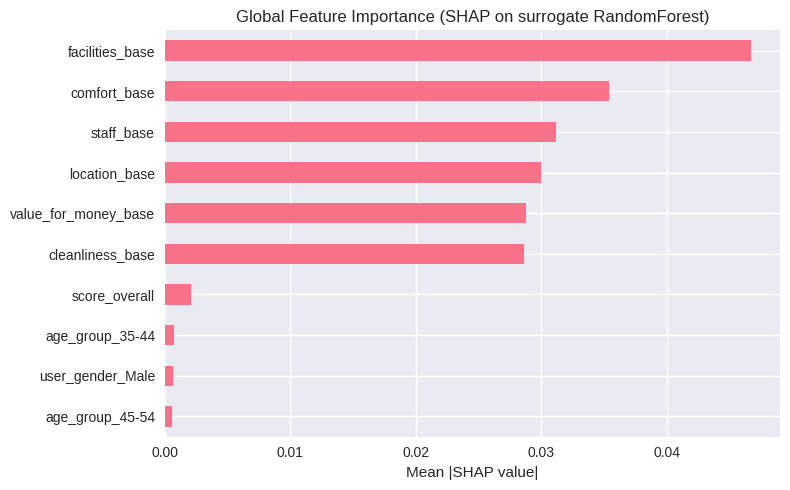


Top features for class 0:
cleanliness_base        0.048551
value_for_money_base    0.043914
facilities_base         0.043723
comfort_base            0.041225
staff_base              0.039362
dtype: float64

Top features for class 1:
facilities_base     0.080032
staff_base          0.055068
comfort_base        0.035730
location_base       0.034368
cleanliness_base    0.027030
dtype: float64

Top features for class 2:
location_base           0.030070
facilities_base         0.026754
comfort_base            0.019712
staff_base              0.015427
value_for_money_base    0.014994
dtype: float64

Top features for class 3:
comfort_base        0.040743
facilities_base     0.032988
staff_base          0.032667
cleanliness_base    0.029382
location_base       0.025682
dtype: float64

Top features for class 4:
staff_base          0.038153
facilities_base     0.033584
cleanliness_base    0.031436
location_base       0.031309
comfort_base        0.030920
dtype: float64

Top features for class 5

In [74]:
# import shap
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier

# # ---------------------------
# # ⚙️ Step 1: Prepare data
# # ---------------------------
# feature_names = X_encoded.columns  # same columns used for training
# X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
# X_test_df  = pd.DataFrame(X_test_scaled, columns=feature_names)
                    
# # Sample small subset for speed
# X_sample = X_train_df.sample(1000, random_state=42)

# # ---------------------------
# # 🧠 Step 2: Get NN predictions (probabilities)
# # ---------------------------
# y_proba = model.predict(X_sample, verbose=0)  # shape = (n_samples, n_classes)
# y_pred = np.argmax(y_proba, axis=1)

# # ---------------------------
# # 🌳 Step 3: Train a fast surrogate model
# # ---------------------------
# # We distill the neural net into a simpler RandomForest
# clf = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=8,
#     random_state=42,
#     n_jobs=-1
# )
# clf.fit(X_sample, y_pred)

# # ---------------------------
# # 🔍 Step 4: Fast SHAP analysis
# # ---------------------------
# explainer = shap.TreeExplainer(clf)
# shap_values = explainer.shap_values(X_test_df)  # fast, one call

# print(f"✅ Got SHAP values for {len(shap_values)} classes")
# print(f"Each SHAP array shape: {shap_values[0].shape}")

# # ---------------------------
# # 🌍 Step 5: Global feature importance
# # ---------------------------
# # Average absolute SHAP values across all classes
# mean_abs = np.mean([np.abs(vals) for vals in shap_values], axis=0)
# mean_abs_per_feature = np.mean(mean_abs, axis=0)
# feat_imp = pd.Series(mean_abs_per_feature, index=feature_names).sort_values(ascending=False)

# # Plot top 10
# plt.figure(figsize=(8, 5))
# feat_imp.head(10).sort_values().plot(kind='barh')
# plt.title("Global Feature Importance (SHAP on surrogate RandomForest)")
# plt.xlabel("Mean |SHAP value|")
# plt.tight_layout()
# plt.show()

# # ---------------------------
# # 🧩 Step 6: Optional – per-class explanation
# # ---------------------------
# for c in range(len(shap_values)):
#     print(f"\nTop features for class {c}:")
#     per_class_imp = np.mean(np.abs(shap_values[c]), axis=0)
#     top = pd.Series(per_class_imp, index=feature_names).sort_values(ascending=False).head(5)
#     print(top)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ---------------------------
# ⚙️ Step 1: Split and scale properly
# ---------------------------
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Separate numeric and categorical columns
num_cols = [
    'star_rating', 'cleanliness_base', 'comfort_base', 'facilities_base',
    'location_base', 'staff_base', 'value_for_money_base', 'score_overall'
]  # 8 numeric features
cat_cols = [c for c in X_encoded.columns if c not in num_cols]

# Scale only numeric columns
scaler = StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train[num_cols])
X_test_scaled_num  = scaler.transform(X_test[num_cols])

# Recombine scaled numeric + categorical features
X_train_scaled = pd.concat(
    [pd.DataFrame(X_train_scaled_num, columns=num_cols, index=X_train.index),
     X_train[cat_cols]], axis=1
)
X_test_scaled = pd.concat(
    [pd.DataFrame(X_test_scaled_num, columns=num_cols, index=X_test.index),
     X_test[cat_cols]], axis=1
)

print("✅ Shapes aligned:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Any NaNs:", X_test_scaled.isna().sum().sum())

# ---------------------------
# ⚙️ Step 2: SHAP surrogate setup
# ---------------------------
feature_names = X_encoded.columns
X_train_df = X_train_scaled.copy()
X_test_df = X_test_scaled.copy()

# Sample subset for SHAP speed
X_sample = X_train_df.sample(1000, random_state=42)

# ---------------------------
# 🧠 Step 3: Neural net predictions
# ---------------------------
y_proba = model.predict(X_sample, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

# ---------------------------
# 🌳 Step 4: Train surrogate RandomForest
# ---------------------------
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_sample, y_pred)

# ---------------------------
# 🔍 Step 5: SHAP on surrogate
# ---------------------------
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_df)

print(f"✅ Got SHAP values for {len(shap_values)} classes")
print(f"Each SHAP array shape: {shap_values[0].shape}")

# ---------------------------
# 🌍 Step 6: Global feature importance
# ---------------------------
mean_abs = np.mean([np.abs(vals) for vals in shap_values], axis=0)
mean_abs_per_feature = np.mean(mean_abs, axis=0)
feat_imp = pd.Series(mean_abs_per_feature, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.head(10).sort_values().plot(kind='barh')
plt.title("Global Feature Importance (SHAP on surrogate RandomForest)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

# ---------------------------
# 🧩 Step 7: Per-class top features
# ---------------------------
for c in range(len(shap_values)):
    print(f"\nTop features for class {c}:")
    per_class_imp = np.mean(np.abs(shap_values[c]), axis=0)
    top = pd.Series(per_class_imp, index=feature_names).sort_values(ascending=False).head(5)
    print(top)



📊 SHAP summary for Class 0


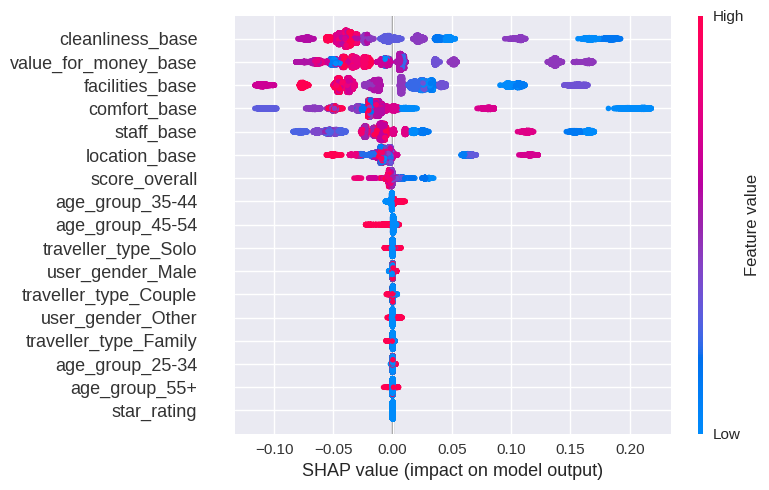


📊 SHAP summary for Class 1


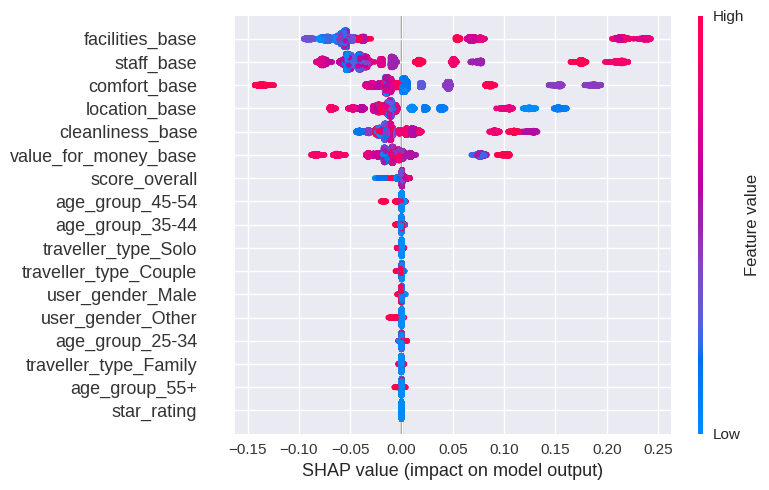


📊 SHAP summary for Class 2


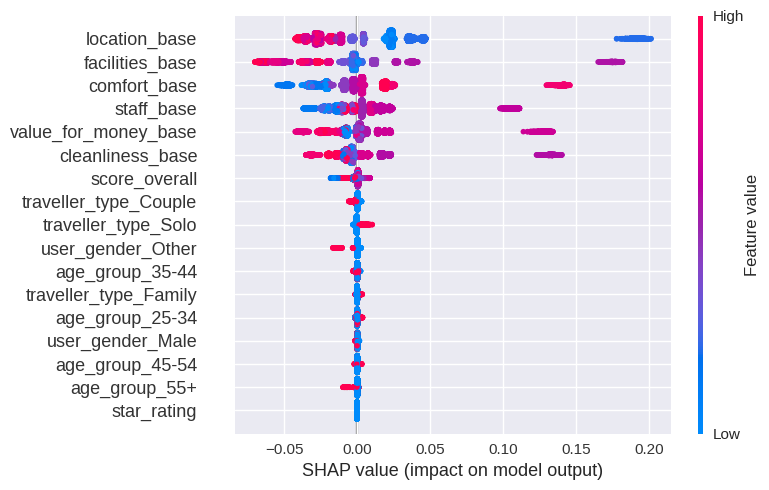


📊 SHAP summary for Class 3


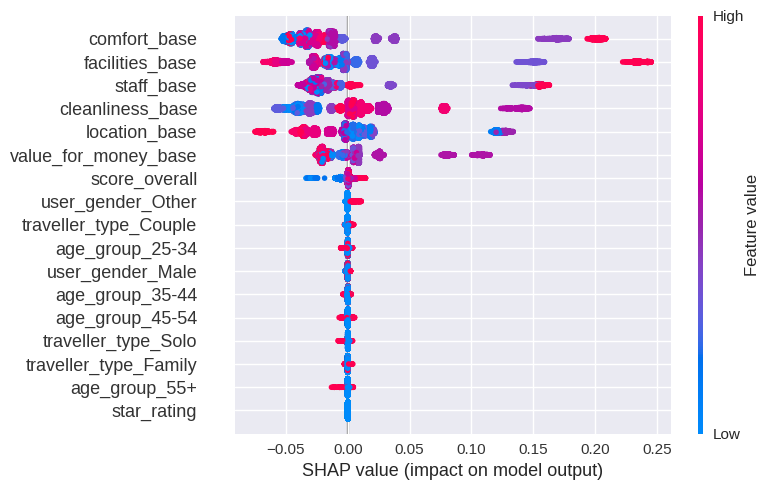


📊 SHAP summary for Class 4


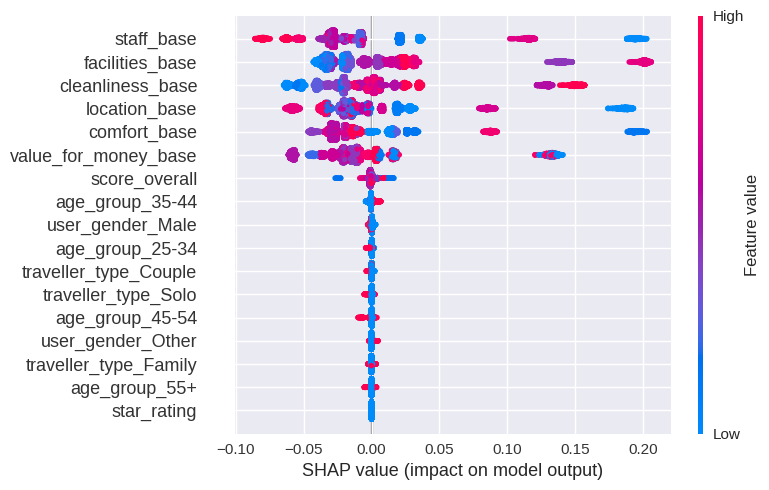


📊 SHAP summary for Class 5


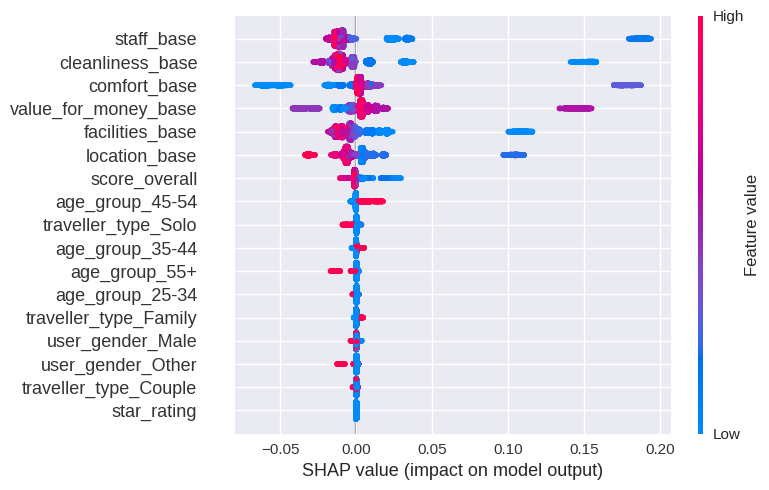


📊 SHAP summary for Class 6


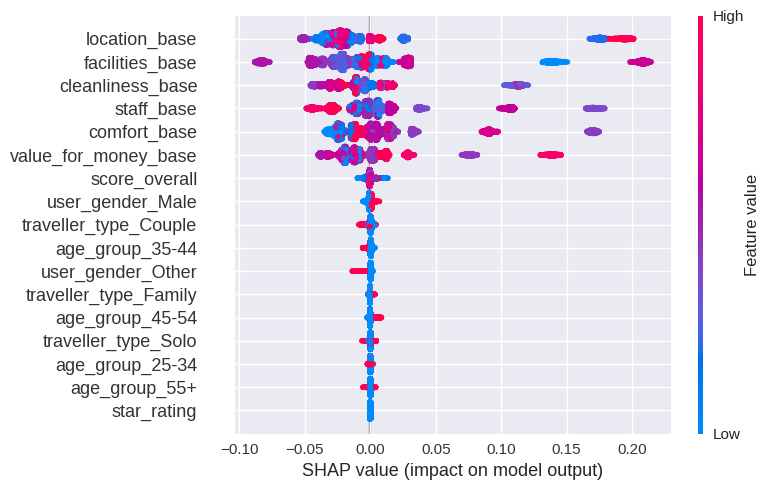


📊 SHAP summary for Class 7


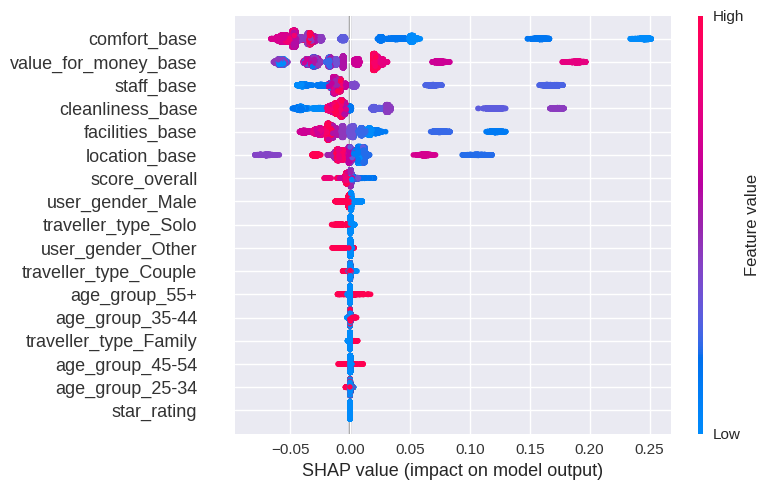


📊 SHAP summary for Class 8


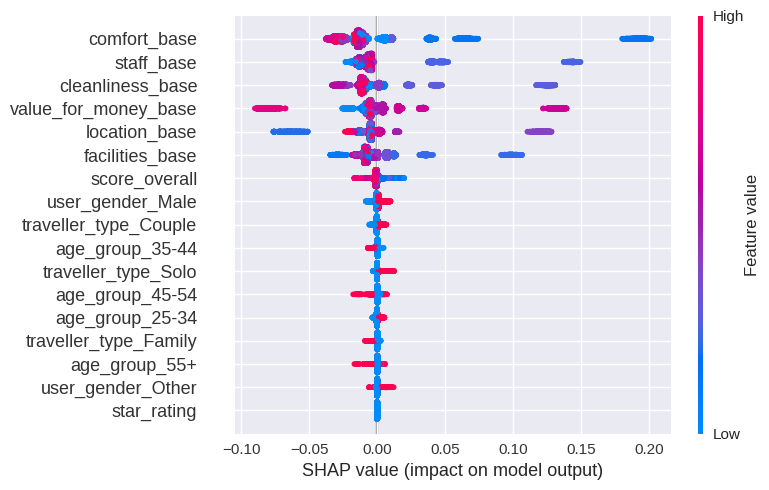


📊 SHAP summary for Class 9


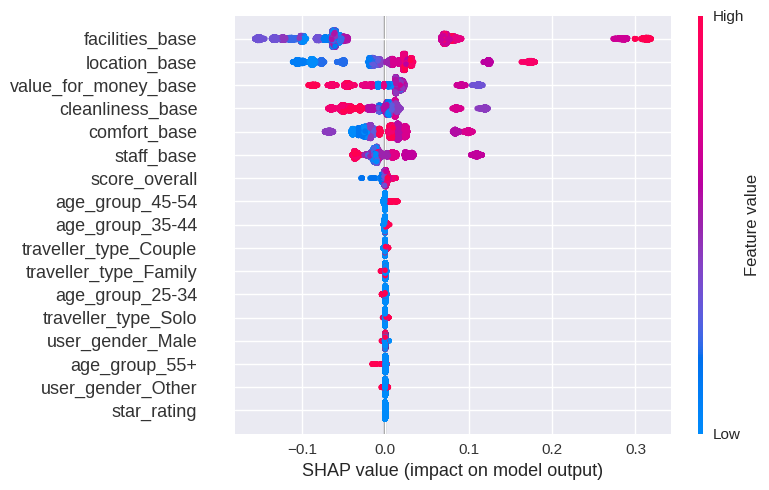


📊 SHAP summary for Class 10


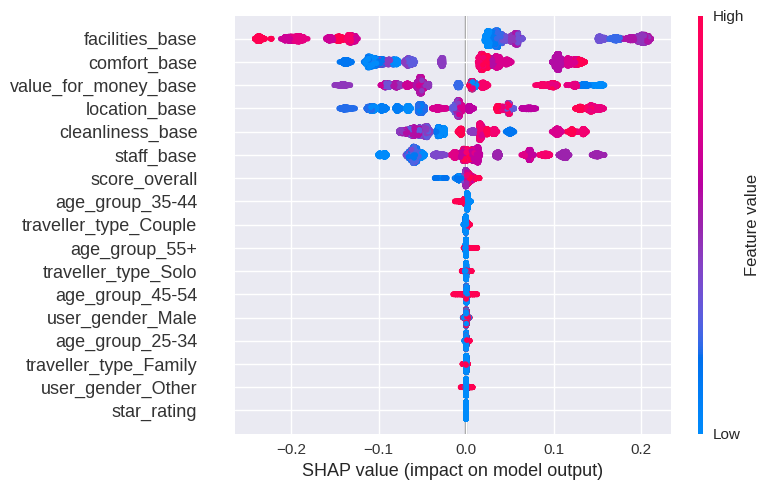

In [75]:
num_classes = len(shap_values)

for c in range(num_classes):
    class_label = f"Class {c}"  # ✅ use f-string so c updates each time
    print(f"\n📊 SHAP summary for {class_label}")
    shap.summary_plot(
        shap_values[c],
        X_test_df,
        feature_names=feature_names,
        plot_size=(8, 5),
        show=True,
        class_names=[class_label]  # wrap in list for SHAP compatibility
    )
    
    

In [76]:
# -------------------------------
# 🧩 SHAP Force Plot (Local View)
# -------------------------------
import numpy as np
import shap
import pandas as pd
shap.initjs()

# # Choose an instance to explain
# i = 0  

# # Predict the class
# pred = model.predict(X_test_scaled[i].reshape(1, -1), verbose=0)
# pred_class = np.argmax(pred, axis=1)[0]
# print(f"🔍 Explaining sample #{i} — Predicted class index: {pred_class}")

# # --- Handle multi-class SHAP values (list of np arrays) ---
# # Each element shap_values[c] has shape (n_samples, n_features)
# base_value = explainer.expected_value[pred_class] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
# sample_values = shap_values[pred_class][i]   # SHAP values for predicted class

# # Prepare feature data
# if isinstance(X, pd.DataFrame):
#     feature_names = X.columns
# else:
#     feature_names = [f"feature_{j}" for j in range(X_test_scaled.shape[1])]
# sample_features = X_test_scaled[i]

# # ✅ Create a proper SHAP Explanation object
# exp = shap.Explanation(
#     values=sample_values,
#     base_values=base_value,
#     data=sample_features,
#     feature_names=feature_names
# )

# # --- Plot the explanation ---
# shap.plots.force(exp)
i = 0
X_test_numeric = X_test_scaled.astype(float).values

# Predict
pred = model.predict(X_test_numeric[i].reshape(1, -1), verbose=0)

pred_class = np.argmax(pred, axis=1)[0]
if pred_class >= len(shap_values):
    print(f"Predicted class {pred_class} not in SHAP values. Using last available class {len(shap_values)-1} instead.")
    pred_class = len(shap_values)-1


# SHAP values for this instance
base_value = explainer.expected_value[pred_class] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
sample_values = shap_values[pred_class][i]

# SHAP Explanation object
exp = shap.Explanation(
    values=sample_values,
    base_values=base_value,
    data=X_test_numeric[i],
    feature_names=X_test_scaled.columns
)

# Plot
shap.plots.force(exp)


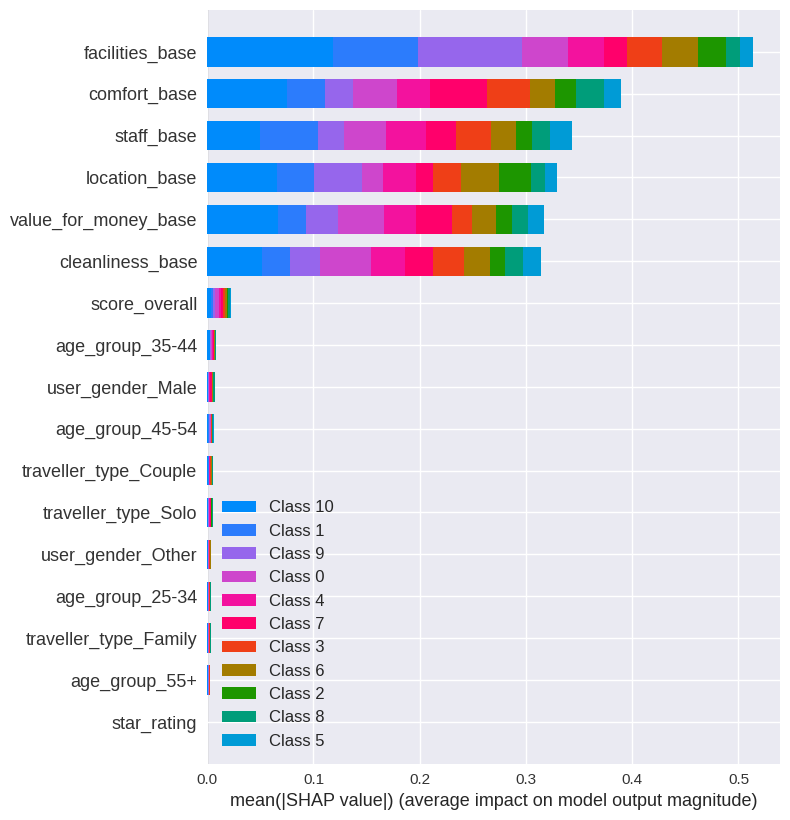

In [77]:
shap.summary_plot(shap_values, X_test_df, feature_names=feature_names, plot_type="bar")

In [78]:
def preprocess_input(raw_input):
    """
    Takes raw input dict and returns scaled input ready for model prediction.
    """
    model_features = X_train.columns.tolist()
    df = pd.DataFrame([raw_input])
    df_encoded = pd.get_dummies(df)
    df_encoded = df_encoded.reindex(columns=model_features, fill_value=0)
    scaled_input = scaler.transform(df_encoded)
    return scaled_input

def predict_country_group(raw_input):
    """
    Takes raw input dict and returns predicted country group label.
    """
    processed_input = preprocess_input(raw_input)
    probabilities = model.predict(processed_input)
    predicted_index = np.argmax(probabilities, axis=1)[0]
    predicted_label = le.inverse_transform([predicted_index])[0]
    return predicted_label



In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [82]:
clf = LogisticRegression()
clf.fit(X_encoded, y_encoded)

LogisticRegression()

In [83]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71      1533
           1       0.57      0.48      0.52      1520
           2       0.52      0.90      0.66       492
           3       0.80      0.53      0.64       996
           4       1.00      0.99      1.00       991
           5       1.00      1.00      1.00       501
           6       0.43      0.16      0.23      1004
           7       0.78      1.00      0.87       980
           8       0.25      0.02      0.04       497
           9       0.83      1.00      0.91      1017
          10       0.68      0.87      0.76      2969

    accuracy                           0.72     12500
   macro avg       0.69      0.70      0.67     12500
weighted avg       0.69      0.72      0.69     12500



In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.72064
Precision (macro): 0.6875050937712213
Recall (macro): 0.6958475917581329
F1 Score (macro): 0.6664458417821736

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71      1533
           1       0.57      0.48      0.52      1520
           2       0.52      0.90      0.66       492
           3       0.80      0.53      0.64       996
           4       1.00      0.99      1.00       991
           5       1.00      1.00      1.00       501
           6       0.43      0.16      0.23      1004
           7       0.78      1.00      0.87       980
           8       0.25      0.02      0.04       497
           9       0.83      1.00      0.91      1017
          10       0.68      0.87      0.76      2969

    accuracy                           0.72     12500
   macro avg       0.69      0.70      0.67     12500
weighted avg       0.69      0.72      0.69     12500


Confusion Matrix:
[[1091    0    0